In [2]:
%run Packages_and_Functions.ipynb
# %run Graph_Generators.ipynb
# %run Metric_Repair_Algorithms.ipynb
import scipy.special
from random import randrange


In [3]:
def powerset(iterable):
    "powerset([1,2,3]) --> () (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))


def SHAP(U,v):
    """
    U is the universe , v is the valuation function (callable).
    Make sure U can be keys for dict
    """
    n = len(U)
    PU = list(map(set, powerset(U)))
    shapley_values = dict()
    for u in U:
        temp = 0
        for S in PU:
            if u not in S:
                Su = S.copy()
                Su.add(u)
                temp += np.power(scipy.special.comb(n-1,len(S)),-1)*(v(Su) - v(S))
        shapley_values[u] = (1/n)*temp
    return shapley_values


def SHAP(U,v):
    """
    U is the universe , v is the valuation function (callable).
    Make sure U can be keys for dict
    """
    n = len(U)
    PU = list(map(set, powerset(U)))
    shapley_values = dict()
    for u in U:
        temp = 0
        for S in PU:
            if u not in S:
                Su = S.copy()
                Su.add(u)
                temp += np.power(scipy.special.comb(n-1,len(S)),-1)*(v(Su) - v(S))
        shapley_values[u] = (1/n)*temp
    return shapley_values


def APPX_SHAP(U,v,it_nu=100):
    """
    approximates shapley value using randomly generated permutations, generally fixed to 100 iterations
    """
    appx_shapley_values = dict()
    
    for u in U:
        appx_shapley_values[u] = 0
    
    for i in range(it_nu):
        Uc = list(U).copy()
        random.shuffle(Uc)
        for u in U:
            S = Uc[:Uc.index(u)]
            Su = S + [u]
            crit = v(Su) - v(S)
            appx_shapley_values[u] += crit
    
    for u in U:
        appx_shapley_values[u] *=(1/it_nu)
    
    
    return appx_shapley_values


def get_hs_indicator(T):
    """
    Given a family of sets T, returns a function that takes a set S and return 1 if it's a HS for T, 0 else
    """
    def HS_T(S):
        for t in T:
            if not set(t) & set(S):
                return 0
        return 1
    return HS_T


def get_cycles_hs(G, light=False):
    """
    Given a graph G, returns a funcion that takes a set of edge S and returns 1 if it's a cover (or light)
    """
    ## TODO: Modify verifier so it can detect light cover as well
    def CYCLE_HS(S):
        return verifier(G,S)
    return CYCLE_HS
 
def graph_shapley_values(G, light = False, approx = 0):
    """
    Given a BROKEN weighted graph G, returns a dictionary of edge: shapley value
    """
    nu = get_cycles_hs(G,light) # Valuation Function: 1 if HS (or light cover)
    E = G.edges(labels=0, sort=1)
    if not approx:
        return SHAP(E,nu)
    else:
        return APPX_SHAP(E,nu,approx)
    
def graph_banzhaf_values(G, light = False, approx = 0):
    """
    Given a BROKEN weighted graph G, returns a dictionary of edge: shapley value
    """
    nu = get_cycles_hs(G,light) # Valuation Function: 1 if HS (or light cover)
    E = G.edges(labels=0, sort=1)
    if not approx:
        return BANZHAF(E,nu)
    else:
        return APPX_BANZHAF(E,nu,approx)

def random_subset(s, criterion=lambda x: randrange(2)):
    return set(filter(criterion, s))

def BANZHAF(U,v):
    n = len(U)
    
    banzhaf_values = dict()
    
    for u in U:
        banzhaf_values[u] = 0
        
    for u in U:
        Uu = list(U).copy()
        Uu.remove(u)
        PU = list(map(set, powerset(Uu)))
        temp = 0
        for S in PU:
            Su = S.copy()
            Su.add(u)
            temp += v(Su) - v(S)
        banzhaf_values[u] = (1/np.power(2,n-1))*temp
    return banzhaf_values

def APPX_BANZHAF(U,v,it_nu=100):
    
    appx_banzhaf_values = dict()
    
    for u in U:
        appx_banzhaf_values[u] = 0
    
    for i in range(it_nu):
        for u in U:
            Uu = list(U).copy()
            Uu.remove(u)
            S = list(random_subset(Uu))
            Su = S + [u]
            crit = v(Su) - v(S)
            appx_banzhaf_values[u] += crit
    
    for u in U:
        appx_banzhaf_values[u] *=(1/it_nu)
    
    return appx_banzhaf_values


def greedy_shapley_HS(G,values, light = False):
    check_hs = get_cycles_hs(G, light)
    S = set()
    SOLN = 0
    while not SOLN:
        e = max(values, key = lambda x: values[x])
        S.add(e)
        SOLN = check_hs(S)
        if not SOLN:
            values.pop(e)
    return S
        

def greedy_iterative_shapley_HS(G, approx=0,light = False):
    H = G.copy()
    check_hs = get_cycles_hs(H, light)
    S = set()
    SOLN = 0
    while not SOLN:
        values = graph_shapley_values(H,approx=approx,light=light,)
        e = max(values, key = lambda x: values[x])
        S.add(e)
        SOLN = check_hs(S)
        if not SOLN:
            values.pop(e)
            H.delete_edge(e)
    return S

def greedy_iterative_banzhaf_HS(G, approx=0,light = False):
    H = G.copy()
    check_hs = get_cycles_hs(H, light)
    S = set()
    SOLN = 0
    while not SOLN:
        values = graph_banzhaf_values(H,approx=approx,light=light)
        e = max(values, key = lambda x: values[x])
        S.add(e)
        SOLN = check_hs(S)
        if not SOLN:
            values.pop(e)
            H.delete_edge(e)
    return S


    
def shapley_heuristic(G, approx = 0, light = False):
    # values = graph_shapley_values(G,light,approx)
    return greedy_iterative_shapley_HS(G, light, approx)

def banzhaf_heuristic(G, approx = 0, light = False):
    # values = graph_banzhaf_values(G,light,approx)
    return greedy_iterative_banzhaf_HS(G,values, light)

In [19]:
# E = [(0,1,10),(0,2,1),(1,2,1),(1,3,10),(2,3,1),(2,4,10),(3,4,1),(3,5,10),(4,5,1)]
# G = Graph(weighted=True)
# G.add_edges(E)
# print(graph_banzhaf_values(G, approx = 500))
# print(graph_banzhaf_values(G))

{(0, 1): 4/25, (0, 2): 79/500, (1, 2): 33/100, (1, 3): 71/500, (2, 3): 153/500, (2, 4): 13/100, (3, 4): 44/125, (3, 5): 79/500, (4, 5): 7/50}
{(0, 1): 39/256, (0, 2): 39/256, (1, 2): 83/256, (1, 3): 33/256, (2, 3): 75/256, (2, 4): 33/256, (3, 4): 83/256, (3, 5): 39/256, (4, 5): 39/256}


In [28]:
# def greedy_shapley_HS(G,values, light = False):
#     check_hs = get_cycles_hs(G, light)
#     S = set()
#     SOLN = 0
#     while not SOLN:
#         e = max(values, key = lambda x: values[x])
#         S.add(e)
#         SOLN = check_hs(S)
#         if not SOLN:
#             values.pop(e)
#     return S
        

# def greedy_iterative_shapley_HS(G,light = False, approx=False):
#     H = G.copy()
#     check_hs = get_cycles_hs(H, light)
#     S = set()
#     SOLN = 0
#     while not SOLN:
#         values = graph_shapley_values(H,light=light,approx=approx)
#         e = max(values, key = lambda x: values[x])
#         S.add(e)
#         SOLN = check_hs(S)
#         if not SOLN:
#             values.pop(e)
#             H.delete_edge(e)
#     return S

# def greedy_iterative_banzhaf_HS(G,light = False, approx=False):
#     H = G.copy()
#     check_hs = get_cycles_hs(H, light)
#     S = set()
#     SOLN = 0
#     while not SOLN:
#         values = graph_banzhaf_values(H,light=light,approx=approx)
#         e = max(values, key = lambda x: values[x])
#         S.add(e)
#         SOLN = check_hs(S)
#         if not SOLN:
#             values.pop(e)
#             H.delete_edge(e)
#     return S


    
# def shapley_heuristic(G, light = False, approx = 0):
#     values = graph_shapley_values(G,light,approx)
#     return greedy_iterative_shapley_HS(G,values, light)

# def banzhaf_heuristic(G, light = False, approx = 0):
#     values = graph_banzhaf_values(G,light,approx)
#     return greedy_iterative_banzhaf_HS(G,values, light)

In [4]:
shap_samples = list()
domr_samples = list()
lhs_samples=list()
# banzhaf_samples=list()
for n in range(10,12):
    G = random_geometric_weighted_graph(n,.5)
    domr_S = domr_alg(G)
    while len(domr_S) == 0: # Make sure the graph is actually broken
        G = random_geometric_weighted_graph(n,.5)
        domr_S = domr_alg(G)
    lhs_samples.append(len(left_edge_heuristic(G)))
    shap_samples.append(len(shapley_heuristic(G))) ## This takes way too much time, even for small instances. I need to debug this
    domr_samples.append(len(domr_S))


KeyboardInterrupt: 

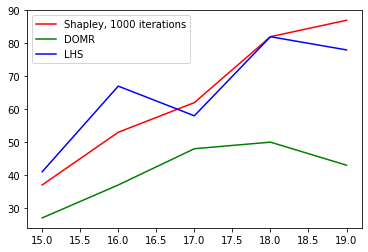

In [187]:
plt.plot(range(15,20),shap_samples,color='red', label = 'Shapley, 1000 iterations')
plt.plot(range(15,20),domr_samples, label = 'DOMR', color = 'green')
plt.plot(range(15,20),lhs_samples,color = 'blue', label = 'LHS')
plt.legend()
plt.show()